In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%matplotlib inline

In [3]:
import sys
sys.path.insert(0,"../python")

In [4]:
import paperI as p1

[1778173912.411495] [stellar-vis1:1168302:0]        ib_iface.c:1231 UCX  ERROR mlx5_0: ibv_create_cq(cqe=4096) failed: Cannot allocate memory : Please set max locked memory (ulimit -l) to 'unlimited' (current: 64 kbytes)
[1778173912.411508] [stellar-vis1:1168302:0]      ucp_worker.c:1415 UCX  ERROR uct_iface_open(rc_verbs/mlx5_0:1) failed: Input/output error


[stellar-vis1.princeton.edu:1168302] pml_ucx.c:309  Error: Failed to create UCP worker


In [5]:
p1.load(verbose=False)

Available models in /scratch/gpfs/changgoo/tigress_classic/:
  - crmhd-16pc-b1-diode-diode-sigma_selfc-Vmax2
  - crmhd-16pc-b1-diode-diode-sigma_selfc-Vmax2-tall
  - crmhd-16pc-b1-diode-lngrad_out-sigma_selfc-Vmax2
  - crmhd-16pc-b1-diode-lngrad_out-sigma_selfc-Vmax2-tall
  - crmhd-16pc-b1-lngrad_out-lngrad_out-sigma_selfc-Vmax2
  - crmhd-16pc-b1-lngrad_out-lngrad_out-sigma_selfc-Vmax2-tall
  - crmhd-8pc-b0.1-diode-lngrad_out-sigma_selfc-Vmax2
  - crmhd-8pc-b1-diode-lngrad_out-sigma27_va1
  - crmhd-8pc-b1-diode-lngrad_out-sigma28_va-1
  - crmhd-8pc-b1-diode-lngrad_out-sigma28_va0
  - crmhd-8pc-b1-diode-lngrad_out-sigma28_va1
  - crmhd-8pc-b1-diode-lngrad_out-sigma29_va-1
  - crmhd-8pc-b1-diode-lngrad_out-sigma29_va0
  - crmhd-8pc-b1-diode-lngrad_out-sigma29_va1
  - crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax10
  - crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax10-rst2
  - crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax2
  - crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax2-fc0.05
  - cr

In [6]:
simgroup = p1.simgroup
group = p1.group

In [7]:
for m,s in simgroup[group].items():
    Zsn = s.par["feedback"]["Z_SN"]
    Mej = s.par["feedback"]["M_ej"]
    dt = 0.1
    mstar = 1 / np.sum(s.pop_synth["snrate"] * dt)
    field = "sfr40"
    if hasattr(s, "hst"):
        h = s.hst
    else:
        h = s.make_monotonic(s.read_hst())
    sfr_avg = h[field].loc[s.tslice_Myr].mean()
    sfr_std = h[field].loc[s.tslice_Myr].std()
    ref_flux = dict(
        mflux=sfr_avg / mstar * mstar,
        pflux_MHD=sfr_avg / mstar * 1.25e5,
        pflux_CR=sfr_avg / mstar * 1.25e5,
        eflux_MHD=sfr_avg / mstar * 1.0e51,
        eflux_CR=sfr_avg / mstar * 1.0e51,
        mZflux=sfr_avg / mstar * Mej * Zsn,
    )
    print(ref_flux)
    print((ref_flux["pflux_MHD"]*(au.Msun*au.km/au.s)/ac.kpc**2/au.yr/ac.k_B).cgs)
    Sigma = h["Sigma_gas"].loc[s.tslice_Myr].mean()
    print(Sigma, Sigma/sfr_avg)

{'mflux': 0.003936294403611913, 'pflux_MHD': 5.200864712484688, 'pflux_CR': 5.200864712484688, 'eflux_MHD': 4.160691769987751e+46, 'eflux_CR': 4.160691769987751e+46, 'mZflux': 8.321383539975502e-05}
24928.326658668935 K / cm3
10.263288015048841 2607.347663231523
{'mflux': 0.003618401188045792, 'pflux_MHD': 4.780845415742287, 'pflux_CR': 4.780845415742287, 'eflux_MHD': 3.82467633259383e+46, 'eflux_CR': 3.82467633259383e+46, 'mZflux': 7.64935266518766e-05}
22915.1271599385 K / cm3
9.268097515757226 2561.3791932128715


mhd Pok_th 3891.4456526621107 3617.9432547436413
mhd 206.25563695386302
mhd Pok_kin 17513.150748161963 16784.545049178207
mhd 928.2375715976137
mhd Pi_B 3412.122158514965 3792.247444856979
mhd 180.85038106274217
crmhd Pok_cr 11447.018285197293 11532.766419602736
crmhd 660.0215095496768
crmhd Pok_th 3830.9597928144312 3716.928887483648
crmhd 220.88860194687092
crmhd Pok_kin 13687.906445085444 13741.40249825563
crmhd 789.2284653849782
crmhd Pi_B 1295.534924639588 1297.9121495336415
crmhd 74.69900853925387
Model    \&        sfr \&   P_cr/k_B \&   P_th/k_B \&  P_kin/k_B \&   Pi_B/k_B \&  P_MHD/k_B \&       Y_cr \&       Y_th \&      Y_kin \&        Y_B \&      Y_MHD\\ 
mhd      \&   3.94e-03 \&    \nodata \&   3.62e+03 \&   1.68e+04 \&   3.79e+03 \&   2.42e+04 \&    \nodata \&     191.76 \&     889.62 \&     201.00 \&    1282.38  \\ 
crmhd    \&   3.62e-03 \&   1.15e+04 \&   3.72e+03 \&   1.37e+04 \&   1.30e+03 \&   1.88e+04 \&     664.97 \&     214.31 \&     792.31 \&      74.84 \&    10

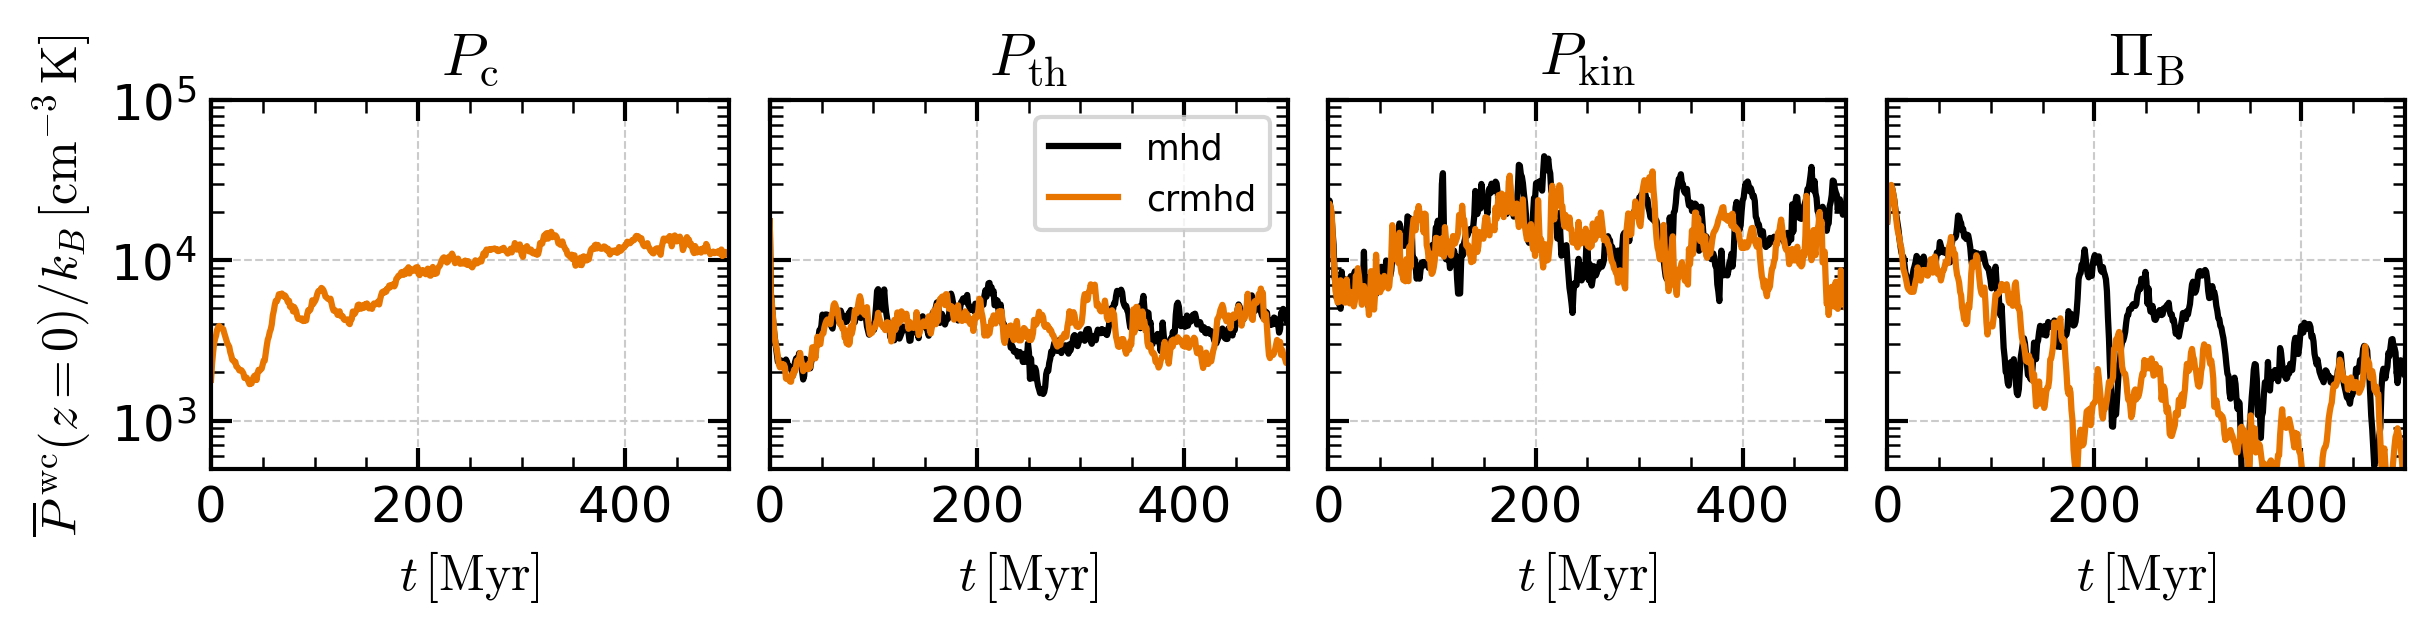

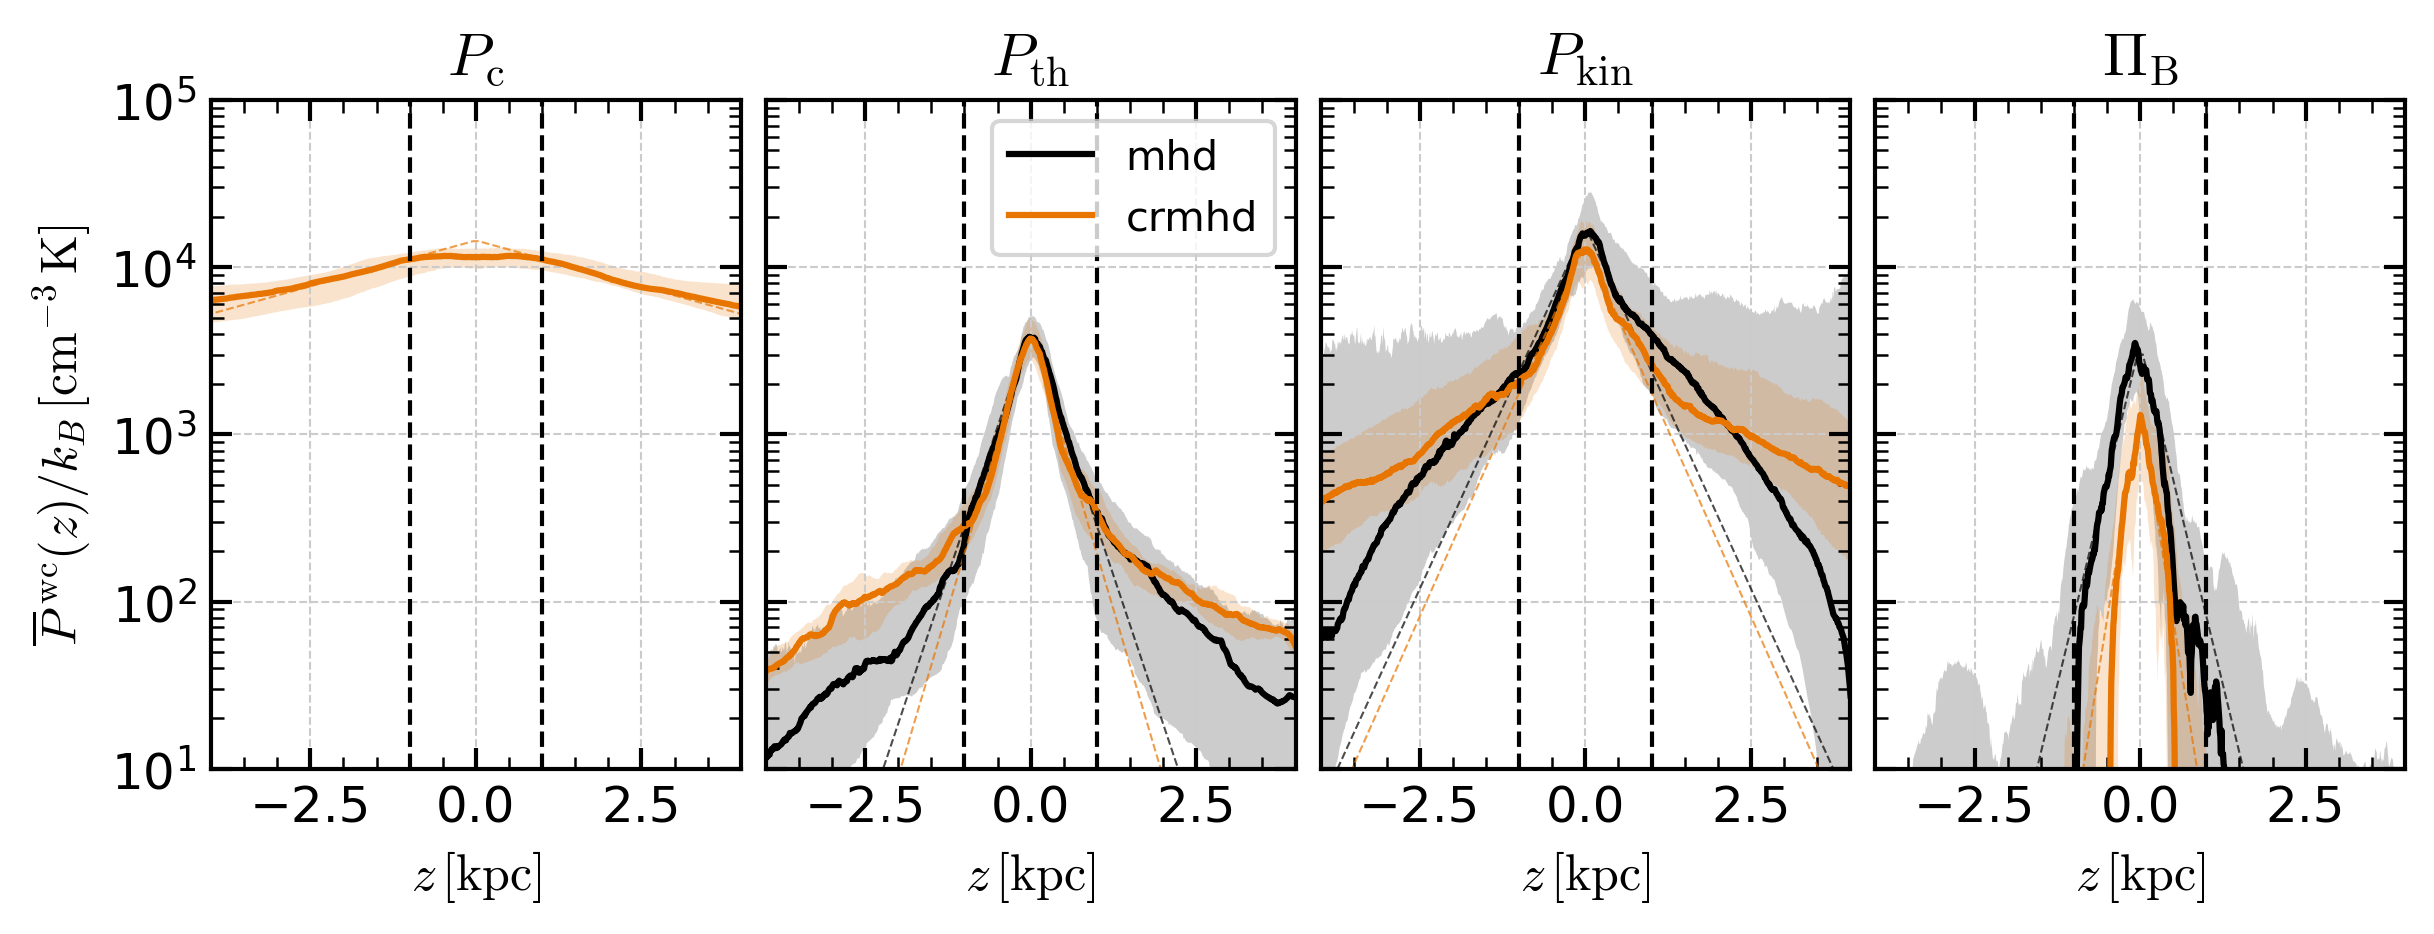

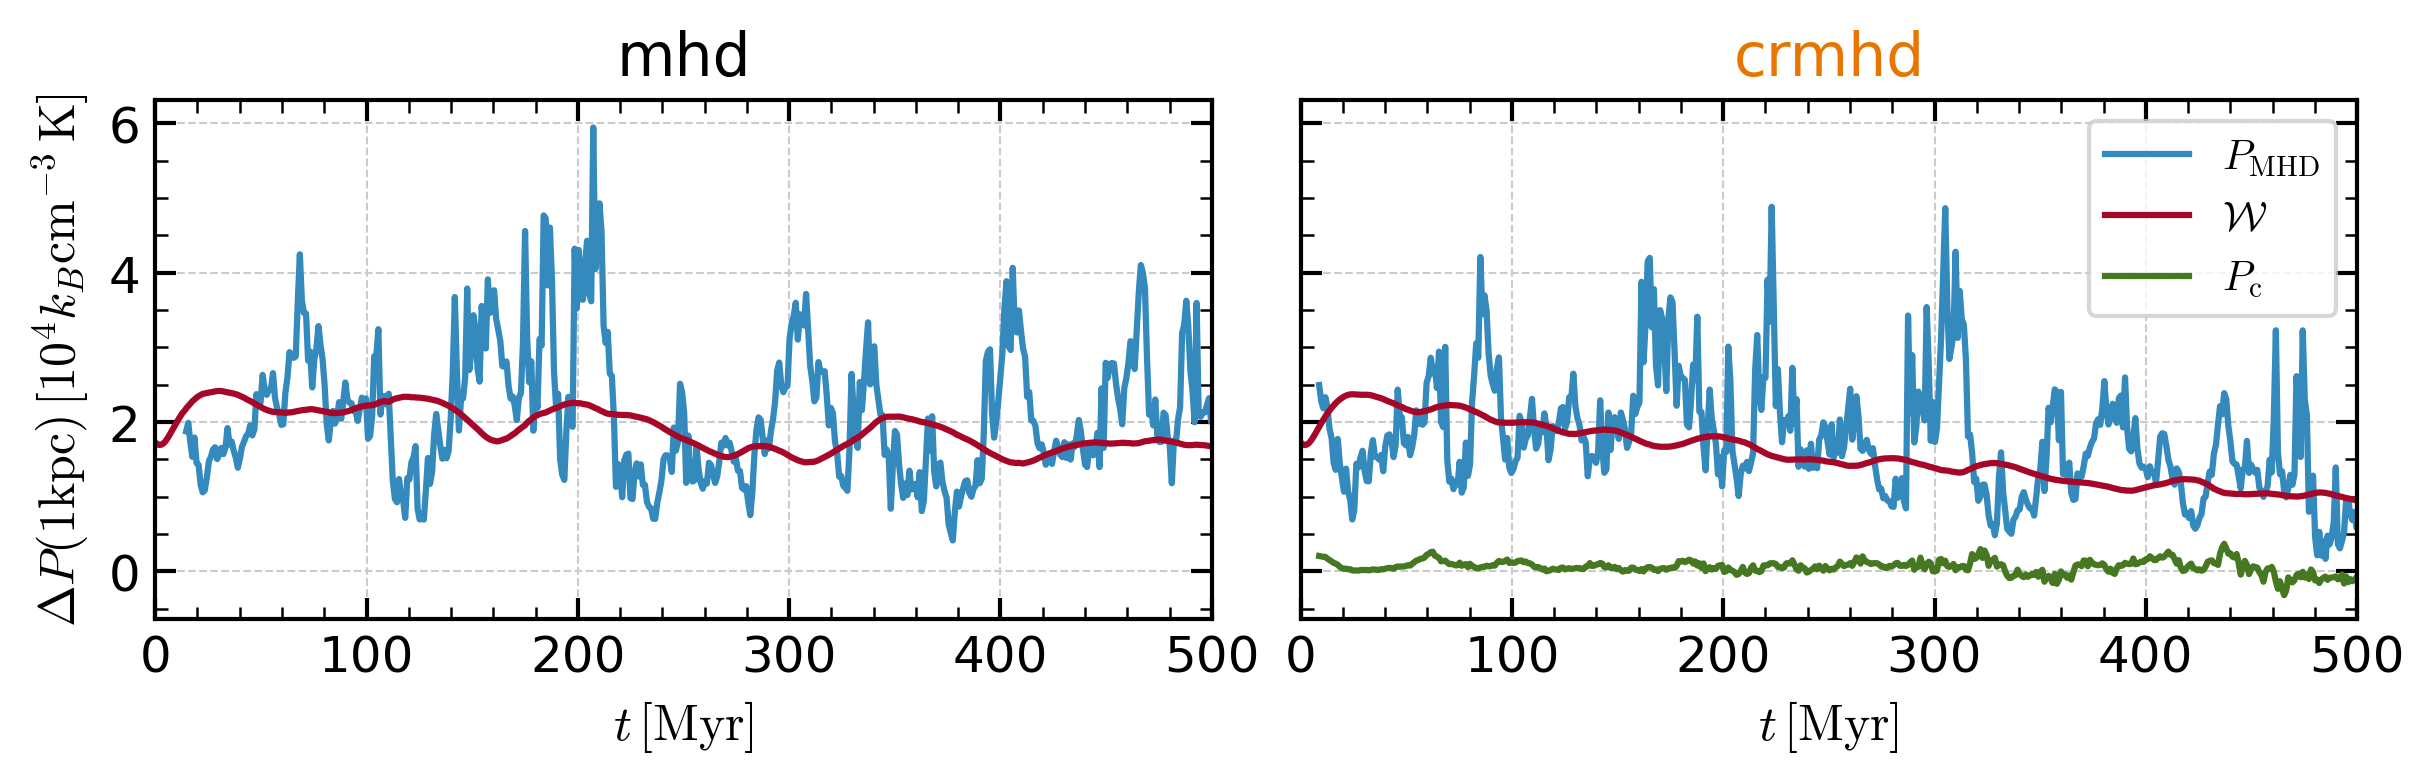

In [7]:
# can use num=1 ... 14 or num="all"
p1.draw_figures(num=2)

In [8]:
sims = p1.simgroup[p1.group]
model_list = list(sims.keys())

In [20]:
import plotting_scripts as ps

In [21]:
ps.setup(p1.outdir, p1.model_name, p1.model_color)

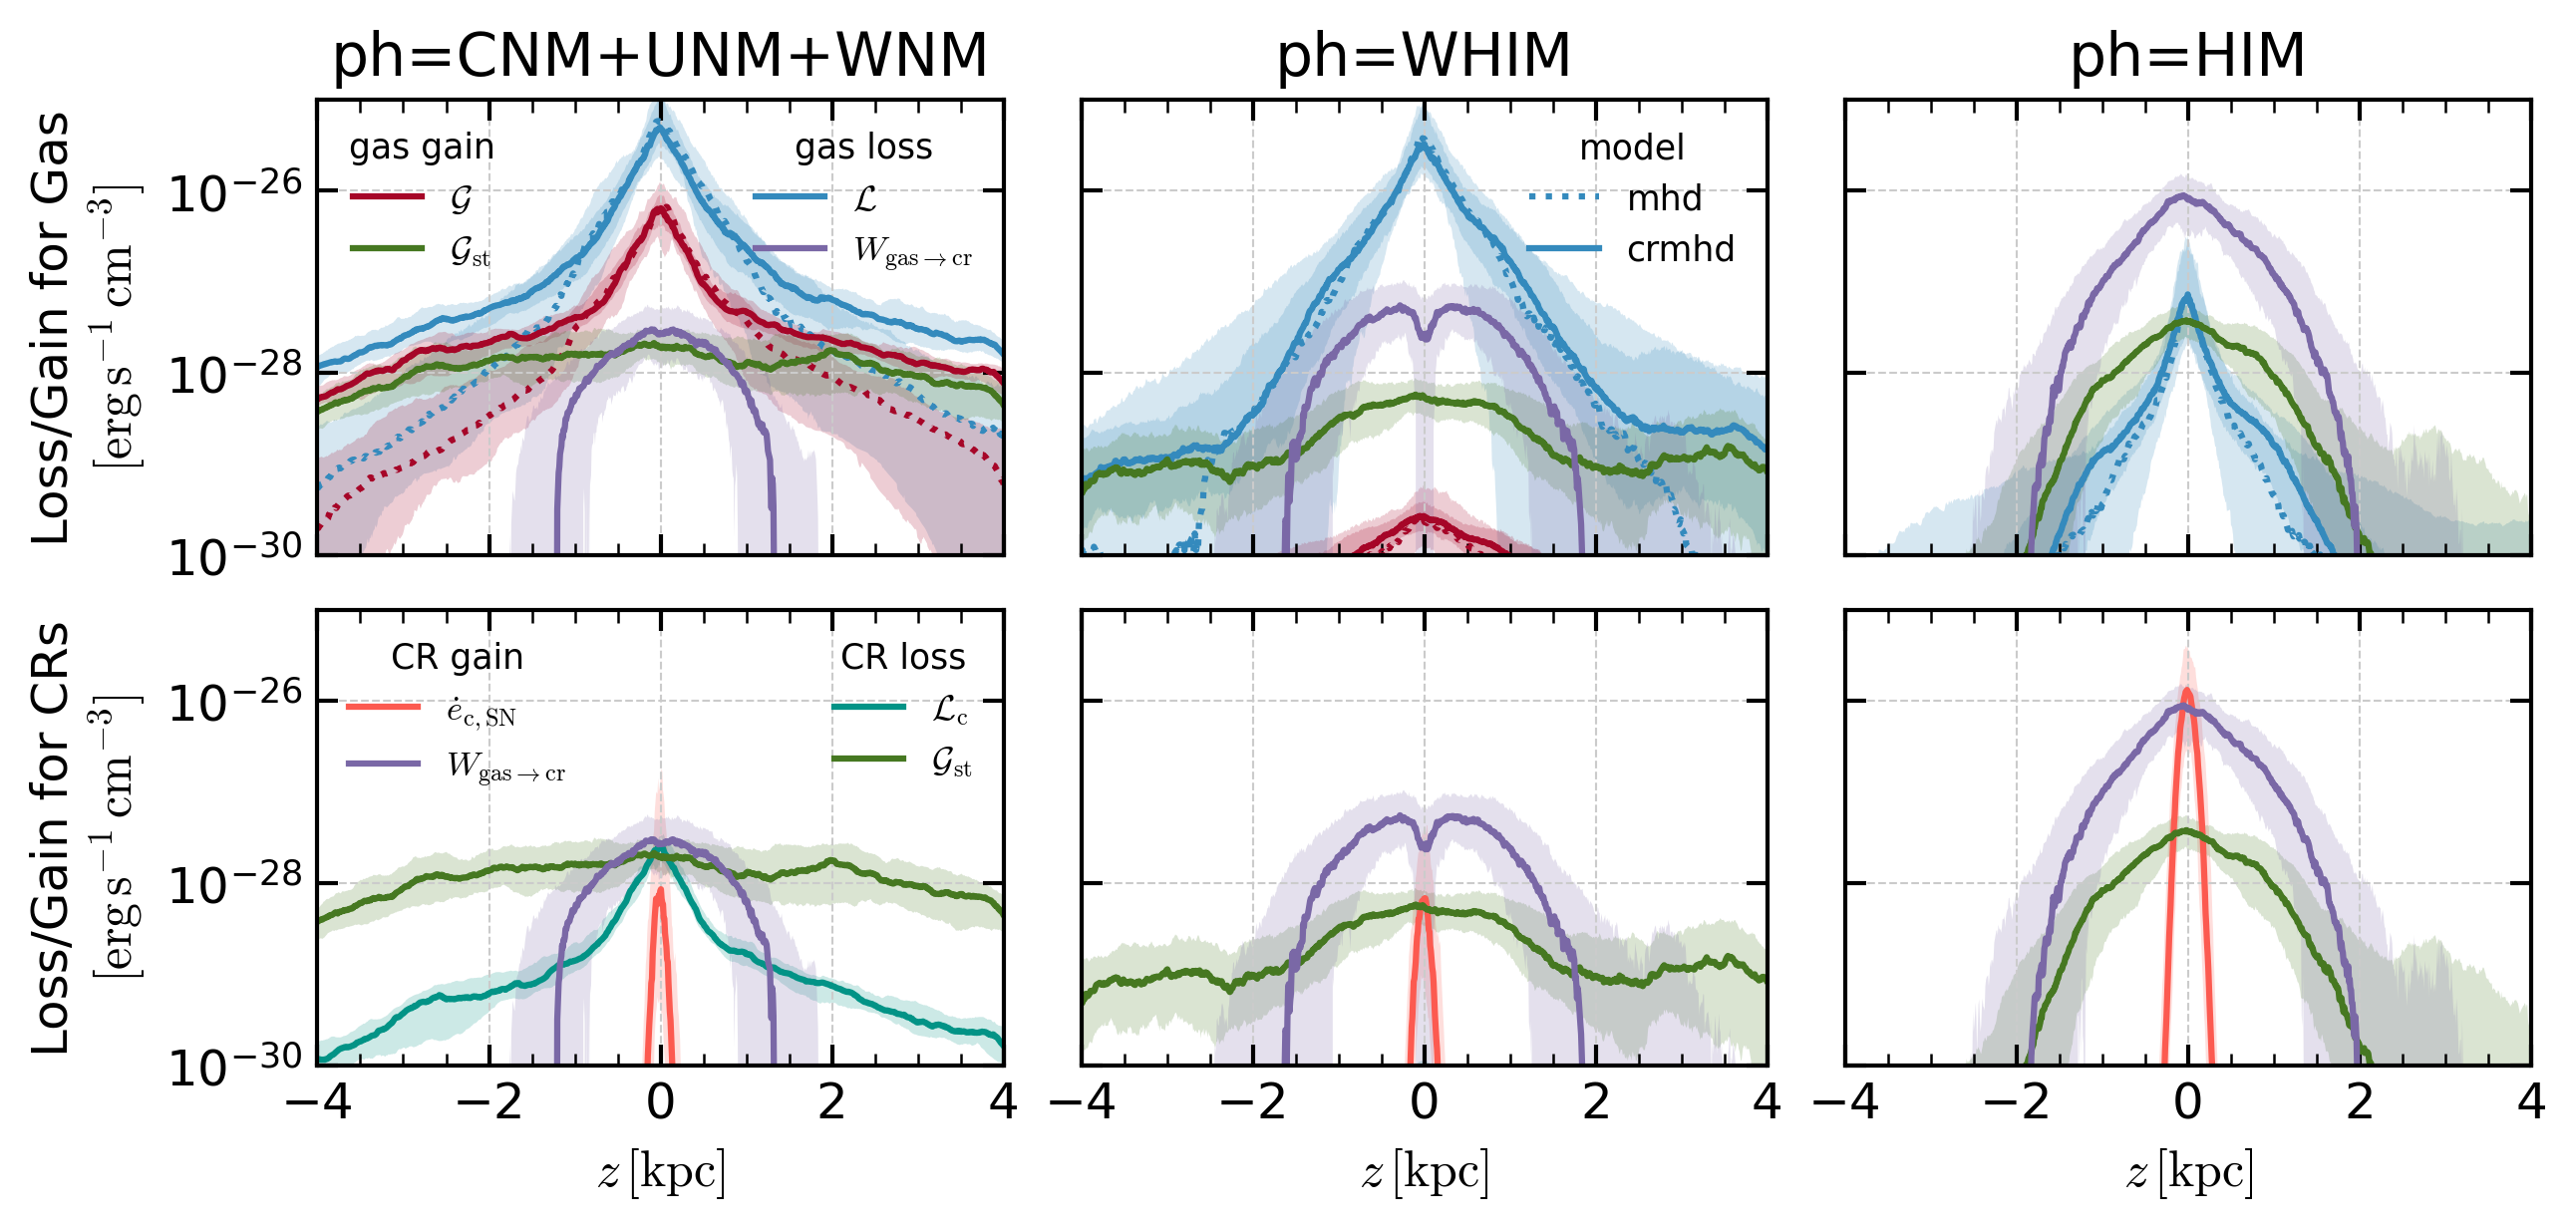

In [23]:
f = ps.plot_gainloss_z(
    simgroup,
    group,
    phases=[["CNM", "UNM", "WNM"],"WHIM","HIM"])

In [25]:
s.options["cosmic_ray"]

True

In [35]:
ps.model_color

{'crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax2-rst': '#E77500',
 'mhd-8pc-b1-diode': '#000000'}

In [37]:
m

'crmhd-8pc-b1-diode-lngrad_out-sigma_selfc-Vmax2-rst'

In [49]:
Ecmean=s.hst["0Ec"][s.tslice].mean()
print(s.hst["0Ec"][s.tslice].min()/Ecmean,s.hst["0Ec"][s.tslice].max()/Ecmean)
print(s.hst["0Ec"][s.tslice].std()/Ecmean)

0.7552922235281566 1.2335769808271997
0.11323192204462937


In [53]:
Etmean=s.hst["totE"][s.tslice].mean()
print(s.hst["totE"][s.tslice].min()/Etmean,s.hst["totE"][s.tslice].max()/Etmean)
print(s.hst["totE"][s.tslice].std()/Etmean)

0.5866915546214633 1.7367323026660504
0.2530805035235335


Text(0, 0.5, '$E/\\overline{E}$')

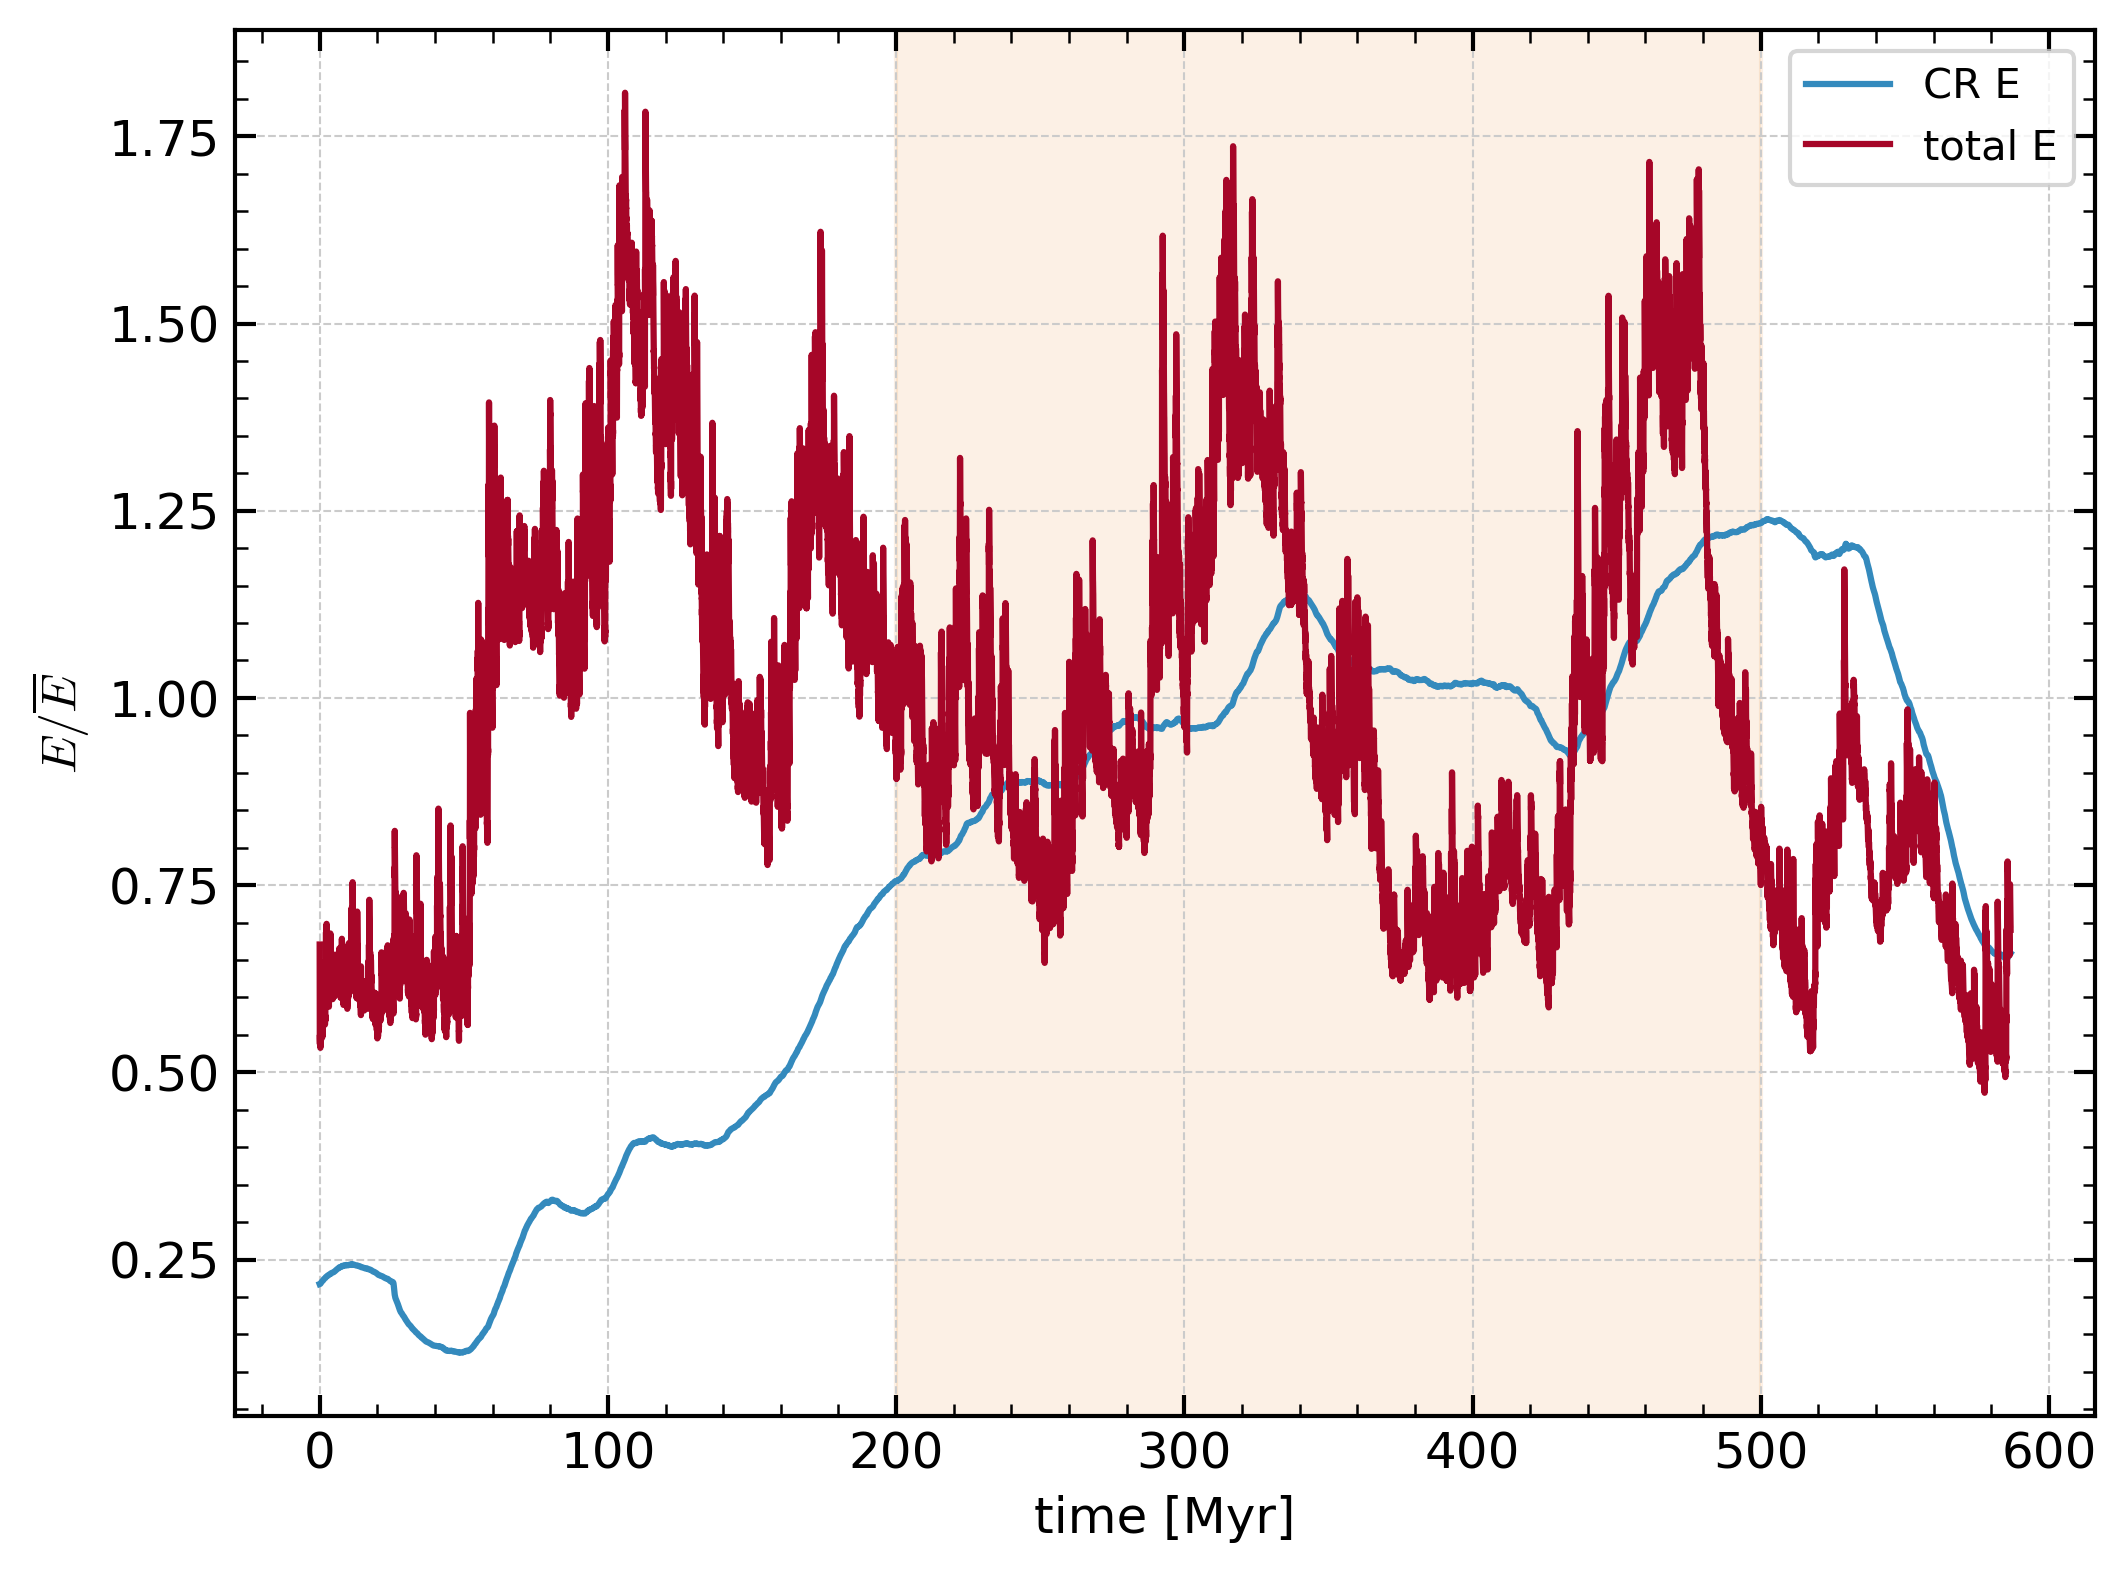

In [58]:
c = ps.model_color[m]
plt.plot(s.hst["time"],s.hst["0Ec"]/Ecmean,label="CR E")
# plt.axhline(Ecmean,color=c,ls="--")
plt.axvspan(s.tslice_Myr.start,s.tslice_Myr.stop,alpha=0.1,color=c)
plt.plot(s.hst["time"],s.hst["totE"]/Etmean,label="total E")
plt.legend()
plt.xlabel("time [Myr]")
plt.ylabel(r"$E/\overline{E}$")
# plt.axhline(Etmean,color=c,ls="--")
